In [1]:
# Notebook 全局导入与超参数。只改这一格，然后从上到下重新运行整个 notebook。
from pathlib import Path
import importlib.util
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

support_path_candidates = [
    Path("cuda_training_support.py"),
    Path("..") / "cuda_training_support.py",
]
SUPPORT_PATH = next((path.resolve() for path in support_path_candidates if path.exists()), None)
if SUPPORT_PATH is None:
    raise FileNotFoundError("找不到 cuda_training_support.py")

support_spec = importlib.util.spec_from_file_location("cuda_training_support", SUPPORT_PATH)
if support_spec is None or support_spec.loader is None:
    raise ImportError(f"无法加载训练辅助模块: {SUPPORT_PATH}")

cuda_training_support = importlib.util.module_from_spec(support_spec)
sys.modules["cuda_training_support"] = cuda_training_support
support_spec.loader.exec_module(cuda_training_support)

PROJECT_ROOT = SUPPORT_PATH.parent

# 如果内核从项目根目录启动，先移除本地 lightgbm 目录对官方包导入的遮蔽。
current_dir = Path.cwd().resolve()
if (current_dir / "lightgbm").is_dir():
    sys.path = [
        path
        for path in sys.path
        if Path(path or current_dir).resolve() != current_dir
    ]

import lightgbm as lgb

NOTEBOOK_RANDOM_SEED = 114514
NOTEBOOK_TEST_SIZE = 0.25
NOTEBOOK_BAYES_N_ITER = 24
NOTEBOOK_CV_FOLDS = 5
NOTEBOOK_MODEL_N_JOBS = 1
NOTEBOOK_SEARCH_N_JOBS = 1
NOTEBOOK_SMOTE_K_NEIGHBORS = 5
NOTEBOOK_BAYES_SCORING = "roc_auc"
NOTEBOOK_BAYES_VERBOSE = 0
NOTEBOOK_TQDM_DESC = "LightGBM BayesSearchCV"
NOTEBOOK_MODEL_OUTPUT_PATH = PROJECT_ROOT / "models" / "lightgbm_cuda_model.txt"
NOTEBOOK_PREPROCESSOR_OUTPUT_PATH = PROJECT_ROOT / "models" / "lightgbm_cuda_preprocessor.joblib"
NOTEBOOK_MANIFEST_OUTPUT_PATH = PROJECT_ROOT / "models" / "lightgbm_cuda_inference_assets.json"

NOTEBOOK_LGBM_SEARCH_SPACES = {
    "num_leaves": Integer(15, 63),
    "learning_rate": Real(5e-5, 5e-3, prior="log-uniform"),
    "n_estimators": Integer(300, 1000),
    "max_depth": Categorical([3, 4, 5, 6, 7, 8, 10]),
    "subsample": Real(0.65, 0.9),
    "colsample_bytree": Real(0.5, 0.9),
    "min_child_samples": Integer(20, 120),
    "min_split_gain": Real(1e-3, 0.2, prior="log-uniform"),
    "reg_alpha": Real(1e-3, 5.0, prior="log-uniform"),
    "reg_lambda": Real(1e-2, 20.0, prior="log-uniform"),
}

NOTEBOOK_CONFIG = cuda_training_support.build_notebook_run_config(
    bayes_n_iter=NOTEBOOK_BAYES_N_ITER,
    cv_folds=NOTEBOOK_CV_FOLDS,
    random_seed=NOTEBOOK_RANDOM_SEED,
    test_size=NOTEBOOK_TEST_SIZE,
    model_n_jobs=NOTEBOOK_MODEL_N_JOBS,
    search_n_jobs=NOTEBOOK_SEARCH_N_JOBS,
    smote_k_neighbors=NOTEBOOK_SMOTE_K_NEIGHBORS,
)
NOTEBOOK_CV = StratifiedKFold(
    n_splits=NOTEBOOK_CONFIG.cv_folds,
    shuffle=True,
    random_state=NOTEBOOK_CONFIG.random_seed,
)
DEFAULT_TARGET_COLUMN = cuda_training_support.DEFAULT_TARGET_COLUMN
DATA_PATH = cuda_training_support.resolve_data_path(start_dir=Path.cwd())

print(
    cuda_training_support.format_notebook_run_summary(
        NOTEBOOK_CONFIG,
        data_path=DATA_PATH,
    )
)
print(f"模型输出路径: {NOTEBOOK_MODEL_OUTPUT_PATH}")
print(f"预处理输出路径: {NOTEBOOK_PREPROCESSOR_OUTPUT_PATH}")
print(f"推理清单路径: {NOTEBOOK_MANIFEST_OUTPUT_PATH}")


随机种子: 114514
数据文件: /root/lightgbm/质谱数据汇总_处理后后后2.csv
测试集比例: 0.25
BayesSearch n_iter: 24
CV folds: 5
模型 n_jobs: 1
搜索 n_jobs: 1
SMOTE k_neighbors: 5
模型输出路径: /root/models/lightgbm_cuda_model.txt
预处理输出路径: /root/models/lightgbm_cuda_preprocessor.joblib
推理清单路径: /root/models/lightgbm_cuda_inference_assets.json


## LightGBM（CUDA-only）

- 第一个代码单元负责 import、路径修正、notebook 全局配置和模型输出路径。
- 第二个代码单元只做数据加载、预处理和诊断输出，不启动训练。
- 第三个代码单元负责唯一一次 BayesSearchCV 训练、评估、特征重要性可视化，并输出完整推理资产。
- 训练设备固定为 `cuda`，禁止 CPU fallback。
- Notebook 训练进度条由 `tqdm.auto` 提供。
- 训练完成后会同时保存 `models/lightgbm_cuda_model.txt`、`models/lightgbm_cuda_preprocessor.joblib` 和 `models/lightgbm_cuda_inference_assets.json`。
- 官方当前不支持 Windows 上的 CUDA 版 LightGBM。需要把训练移动到 Linux 或 WSL2，并先执行：

```bash
pip install -r requirements.txt
pip uninstall -y lightgbm
pip install lightgbm --no-binary lightgbm --config-settings=cmake.define.USE_CUDA=ON
```


In [2]:
# 加载数据、预处理并输出训练前诊断。
random_seed = NOTEBOOK_CONFIG.random_seed

data = cuda_training_support.load_training_dataframe(
    data_path=DATA_PATH,
    random_seed=random_seed,
)
retention_time_raw = data['RETENTION_TIME'].copy()
retention_time_numeric = pd.to_numeric(retention_time_raw, errors='coerce')
data['RETENTION_TIME'] = retention_time_numeric.astype('float64')

prepared = cuda_training_support.prepare_lightgbm_training_data(
    data,
    target_column=DEFAULT_TARGET_COLUMN,
    random_state=NOTEBOOK_CONFIG.random_seed,
    test_size=NOTEBOOK_CONFIG.test_size,
    smote_k_neighbors=NOTEBOOK_CONFIG.smote_k_neighbors,
)
X_train = prepared["X_train"]
X_test = prepared["X_test"]
y_train = prepared["y_train"]
y_test = prepared["y_test"]
scaler = prepared["scaler"]

print("=== 训练前诊断 ===")
print("样本总数:", len(data))
print("标签分布:")
print(data[DEFAULT_TARGET_COLUMN].value_counts())
print()
print("转换前 RETENTION_TIME 的示例值：")
print(retention_time_raw.head())
print()
non_numeric = retention_time_numeric.isna()
print("非数值数据数量：", non_numeric.sum())
print("非数值数据示例：")
print(retention_time_raw.loc[non_numeric].unique())
print()
print("过采样方法:", "notebook_smote")
print("过采样后的训练集形状:", X_train.shape)
print("测试集形状:", X_test.shape)
print("过采样后的标签分布:")
print(pd.Series(y_train).value_counts())
print()

lgbm_version = cuda_training_support.validate_lightgbm_cuda_build(
    random_state=NOTEBOOK_CONFIG.random_seed,
)
print("LightGBM CUDA preflight:", lgbm_version)


=== 训练前诊断 ===
样本总数: 16806
标签分布:
0    10920
1     5886
Name: 毒性, dtype: int64

转换前 RETENTION_TIME 的示例值：
0    4.07435
1      2.354
2        NaN
3      7.557
4     13.870
Name: RETENTION_TIME, dtype: object

非数值数据数量： 3266
非数值数据示例：
[nan '17.9  and 18.5']

过采样方法: notebook_smote
过采样后的训练集形状: (16380, 14)
测试集形状: (4202, 14)
过采样后的标签分布:
0    8190
1    8190
Name: 毒性, dtype: int64

LightGBM CUDA preflight: 4.6.0


LightGBM BayesSearchCV:   0%|          | 0/24 [00:00<?, ?iter/s]

最佳参数组合: OrderedDict([('colsample_bytree', 0.5), ('learning_rate', 0.004999999999999999), ('max_depth', 5), ('min_child_samples', 20), ('min_split_gain', 0.001), ('n_estimators', 360), ('num_leaves', 63), ('reg_alpha', 0.001), ('reg_lambda', 0.1406267276533374), ('subsample', 0.9)])
最佳交叉验证AUC: 0.8672730674562177
模型已保存到: /root/models/lightgbm_cuda_model.txt
预处理包已保存到: /root/models/lightgbm_cuda_preprocessor.joblib
推理清单已保存到: /root/models/lightgbm_cuda_inference_assets.json

=== 训练集性能 ===
AUC               : 0.9148
Accuracy          : 0.8353
Balanced Accuracy : 0.8353
Precision         : 0.8423
Recall            : 0.8250
F1                : 0.8336
Specificity       : 0.8455

=== 测试集性能 ===
AUC               : 0.8172
Accuracy          : 0.7544
Balanced Accuracy : 0.7340
Precision         : 0.6447
Recall            : 0.6658
F1                : 0.6551
Specificity       : 0.8022

=== 泛化差距（训练集 - 测试集） ===
AUC               : +0.0976
Accuracy          : +0.0809
Balanced Accuracy : +0.1013
Precision

<Figure size 1000x600 with 0 Axes>

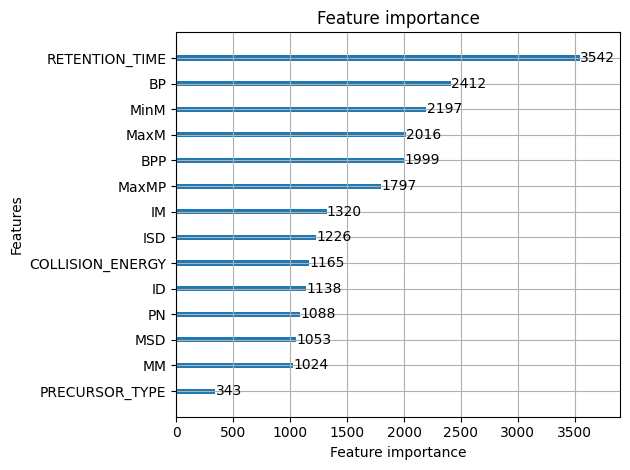

In [3]:
# 唯一训练块：BayesSearchCV 训练、评估、可视化并保存模型。
lgb_model = cuda_training_support.build_lgbm_classifier(
    random_state=NOTEBOOK_CONFIG.random_seed,
    model_n_jobs=NOTEBOOK_CONFIG.model_n_jobs,
)

bayes_search = BayesSearchCV(
    estimator=lgb_model,
    search_spaces=NOTEBOOK_LGBM_SEARCH_SPACES,
    n_iter=NOTEBOOK_CONFIG.bayes_n_iter,
    cv=NOTEBOOK_CV,
    scoring=NOTEBOOK_BAYES_SCORING,
    n_jobs=NOTEBOOK_CONFIG.search_n_jobs,
    verbose=NOTEBOOK_BAYES_VERBOSE,
    random_state=NOTEBOOK_CONFIG.random_seed,
)

progress_bar = tqdm(total=NOTEBOOK_CONFIG.bayes_n_iter, desc=NOTEBOOK_TQDM_DESC, unit="iter")
progress_state = {"completed": 0}


def update_training_progress(_optim_result):
    progress_state["completed"] += 1
    progress_bar.update(1)
    progress_bar.set_postfix(completed=progress_state["completed"], refresh=False)
    return False


try:
    bayes_search.fit(X_train, y_train, callback=update_training_progress)
finally:
    progress_bar.close()

best_lgb = bayes_search.best_estimator_

y_train_pred = best_lgb.predict(X_train)
y_train_proba = best_lgb.predict_proba(X_train)[:, 1]
y_test_pred = best_lgb.predict(X_test)
y_test_proba = best_lgb.predict_proba(X_test)[:, 1]

train_metrics = {
    "AUC": roc_auc_score(y_train, y_train_proba),
    "Accuracy": accuracy_score(y_train, y_train_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_train, y_train_pred),
    "Precision": precision_score(y_train, y_train_pred),
    "Recall": recall_score(y_train, y_train_pred),
    "F1": f1_score(y_train, y_train_pred),
}

tn, fp, fn, tp = confusion_matrix(y_train, y_train_pred).ravel()
train_metrics["Specificity"] = tn / (tn + fp)

test_metrics = {
    "AUC": roc_auc_score(y_test, y_test_proba),
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall": recall_score(y_test, y_test_pred),
    "F1": f1_score(y_test, y_test_pred),
}

tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
test_metrics["Specificity"] = tn / (tn + fp)

test_confusion_matrix = confusion_matrix(y_test, y_test_pred)

saved_artifacts = cuda_training_support.save_lightgbm_inference_artifacts(
    estimator=best_lgb,
    prepared=prepared,
    model_path=NOTEBOOK_MODEL_OUTPUT_PATH,
    preprocessor_path=NOTEBOOK_PREPROCESSOR_OUTPUT_PATH,
    manifest_path=NOTEBOOK_MANIFEST_OUTPUT_PATH,
    target_column=DEFAULT_TARGET_COLUMN,
    data_path=DATA_PATH,
    random_seed=NOTEBOOK_CONFIG.random_seed,
    test_size=NOTEBOOK_CONFIG.test_size,
    smote_k_neighbors=NOTEBOOK_CONFIG.smote_k_neighbors,
    scoring=NOTEBOOK_BAYES_SCORING,
)

print("最佳参数组合:", bayes_search.best_params_)
print("最佳交叉验证AUC:", bayes_search.best_score_)
print(f"模型已保存到: {saved_artifacts['model_path']}")
print(f"预处理包已保存到: {saved_artifacts['preprocessor_path']}")
print(f"推理清单已保存到: {saved_artifacts['manifest_path']}")
print()
print("=== 训练集性能 ===")
for metric, value in train_metrics.items():
    print(f"{metric:<18}: {value:.4f}")
print()
print("=== 测试集性能 ===")
for metric, value in test_metrics.items():
    print(f"{metric:<18}: {value:.4f}")
print()
print("=== 泛化差距（训练集 - 测试集） ===")
for metric in ["AUC", "Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1", "Specificity"]:
    print(f"{metric:<18}: {train_metrics[metric] - test_metrics[metric]:+.4f}")
print()
print("测试集混淆矩阵:")
print(test_confusion_matrix)

plt.figure(figsize=(10, 6))
lgb.plot_importance(best_lgb, max_num_features=20)
plt.tight_layout()
plt.show()
